# Classification Model Comparison

Put `train.csv` and `test.csv` in the same directory as this notebook.

- Set `TARGET_COLUMN` to your target column.
- No feature preprocessing is performed.
- Stratified K-fold CV and hyperparameter tuning use **train.csv only**.
- `test.csv` is used only for final evaluation.
- The final cell reports **Accuracy, Balanced Accuracy, Precision, Recall, F1 and ROC-AUC when available**.
- A **confusion matrix** is displayed for every model.
- For binary classification, ROC-AUC is reported normally.
- For multiclass classification, weighted one-vs-one ROC-AUC is used when the model provides probabilities or decision scores.


In [ ]:
# Common imports and data loading
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

TARGET_COLUMN = "target"   # <-- CHANGE THIS

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

X = train.drop(columns=[TARGET_COLUMN])
y = train[TARGET_COLUMN]

X_test = test.drop(columns=[TARGET_COLUMN])
y_test = test[TARGET_COLUMN]

# StratifiedKFold keeps class proportions similar across folds.
CV = StratifiedKFold(n_splits=2, shuffle=True, random_state=0)

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Number of classes:", y.nunique())
print("Classes:", sorted(y.unique()))


Train shape: (40837, 113)
Test shape : (10210, 113)
Number of classes: 2
Classes: [np.int64(0), np.int64(1)]


## 1. Logistic Regression

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

classifier = LogisticRegression(
    max_iter=1000,
    random_state=0
)

# C: inverse regularization strength; smaller values apply stronger regularization.
# penalty: type of regularization used to control model complexity.
# solver: optimization algorithm used to fit the model.
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy", n_iter=3,
    n_jobs=1
)

grid.fit(X, y)
classifier = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)


Best parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}
Best 2-Fold CV Accuracy: 0.7115605913876833


## 2. K-Nearest Neighbour (KNN)

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV

classifier = KNeighborsClassifier()

# n_neighbors: number of nearby samples used to vote for the class.
# weights: determines whether closer neighbours have more influence.
# p: distance metric power; 1 = Manhattan distance, 2 = Euclidean distance.
param_grid = {
    "n_neighbors": [3, 5, 7, 11],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy", n_iter=3,
    n_jobs=1
)

grid.fit(X, y)
classifier = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)


Best parameters: {'weights': 'uniform', 'p': 1, 'n_neighbors': 11}
Best 2-Fold CV Accuracy: 0.6939540276999582


## 3. Support Vector Machine + Kernel SVM

In [4]:
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import RandomizedSearchCV

# Use nonlinear SVM kernels for smaller datasets.
# Use LinearSVC for larger datasets because RBF/poly SVMs
# become computationally expensive as the number of samples grows.

N_SAMPLES = X.shape[0]

if N_SAMPLES < 10000:

    classifier = SVC(
        probability=True,
        random_state=0
    )

    param_grid = [
        {
            "kernel": ["rbf"],
            "C": [0.1, 1, 10, 100],
            "gamma": ["scale", "auto"]
        },
        {
            "kernel": ["poly"],
            "C": [0.1, 1, 10],
            "gamma": ["scale", "auto"],
            "degree": [2, 3]
        }
    ]

else:

    classifier = LinearSVC(
        random_state=0,
        max_iter=5000
    )

    param_grid = {
        "C": [0.1, 1, 10, 100]
    }


grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy",
    n_iter=3,
    n_jobs=-1,
    random_state=0
)

grid.fit(X, y)

classifier = grid.best_estimator_

print(
    "SVM mode:",
    "RBF/Poly" if N_SAMPLES < 10000 else "LinearSVC"
)
print("Training samples:", N_SAMPLES)
print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)

SVM mode: LinearSVC
Training samples: 40837
Best parameters: {'C': 100}
Best 2-Fold CV Accuracy: 0.7112912188255327


## 4. Naive Bayes

In [5]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV

classifier = GaussianNB()

# var_smoothing: adds a small value to feature variances for numerical stability.
param_grid = {
    "var_smoothing": [1e-11, 1e-9, 1e-7, 1e-5]
}

grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy", n_iter=3,
    n_jobs=1
)

grid.fit(X, y)
classifier = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)


Best parameters: {'var_smoothing': 1e-11}
Best 2-Fold CV Accuracy: 0.6469627301279453


## 5. Decision Tree

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

classifier = DecisionTreeClassifier(
    random_state=0
)

# max_depth: maximum tree depth; controls model complexity.
# min_samples_split: minimum samples needed to split an internal node.
# min_samples_leaf: minimum samples allowed in a leaf.
# criterion: function used to measure the quality of a split.
param_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy", n_iter=3,
    n_jobs=1
)

grid.fit(X, y)
classifier = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)


Best parameters: {'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'gini'}
Best 2-Fold CV Accuracy: 0.7100669445102572


## 6. Random Forest

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

classifier = RandomForestClassifier(
    random_state=0,
    n_jobs=1
)

# n_estimators: number of decision trees in the forest.
# max_depth: maximum depth of each tree; controls complexity.
# min_samples_split: minimum samples needed to split a node.
# max_features: number of features considered when looking for each split.
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"]
}

grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy", n_iter=3,
    n_jobs=1
)

grid.fit(X, y)
classifier = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)


Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 20}
Best 2-Fold CV Accuracy: 0.7156500134984303


## 7. XGBoost Classifier

In [8]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

classifier = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=1.0,
    random_state=0,
    eval_metric="logloss",
    n_jobs=1
)

# n_estimators: number of boosting trees.
# learning_rate: size of each boosting step.
# max_depth: maximum depth of each tree; controls complexity.
# subsample: fraction of training rows used by each tree; can reduce overfitting.
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0]
}

grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy", n_iter=3,
    n_jobs=1
)

grid.fit(X, y)
classifier = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)


Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
Best 2-Fold CV Accuracy: 0.7197394679898674


## 8. LightGBM Classifier

In [9]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

classifier = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    random_state=0,
    verbosity=-1,
    n_jobs=1
)

# n_estimators: number of boosting iterations.
# learning_rate: contribution of each boosting tree.
# num_leaves: controls tree complexity; larger values can model more complex patterns.
# max_depth: limits tree depth; -1 means no explicit limit.
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 10]
}

grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy", n_iter=3,
    n_jobs=1
)

grid.fit(X, y)
classifier = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)


Best parameters: {'num_leaves': 31, 'n_estimators': 100, 'max_depth': -1, 'learning_rate': 0.05}
Best 2-Fold CV Accuracy: 0.7191027460931126


## 9. CatBoost Classifier

In [10]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

classifier = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    loss_function="MultiClass",
    verbose=False,
    random_seed=0,
    thread_count=-1
)

# iterations: number of boosting rounds.
# learning_rate: contribution of each boosting round.
# depth: depth of the trees; higher values increase model complexity.
param_grid = {
    "iterations": [100, 200],
    "learning_rate": [0.05, 0.1],
    "depth": [4, 6, 8]
}

grid = RandomizedSearchCV(
    classifier,
    param_grid,
    cv=CV,
    scoring="accuracy", n_iter=3,
    n_jobs=1
)

grid.fit(X, y)
classifier = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best 2-Fold CV Accuracy:", grid.best_score_)


Best parameters: {'learning_rate': 0.1, 'iterations': 100, 'depth': 6}
Best 2-Fold CV Accuracy: 0.7160173292530594


## Final Test-Set Evaluation


Logistic Regression
Best parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 1}
CV ROC-AUC: 0.6265575894483062
Test Accuracy: 0.7105778648383937
Balanced Accuracy: 0.5118515384762162
Weighted Precision: 0.6472918710401712
Weighted Recall: 0.7105778648383937
Weighted F1: 0.6122880058553196
Test ROC-AUC: 0.62397284951738

Confusion Matrix:
[[7129  139]
 [2816  126]]


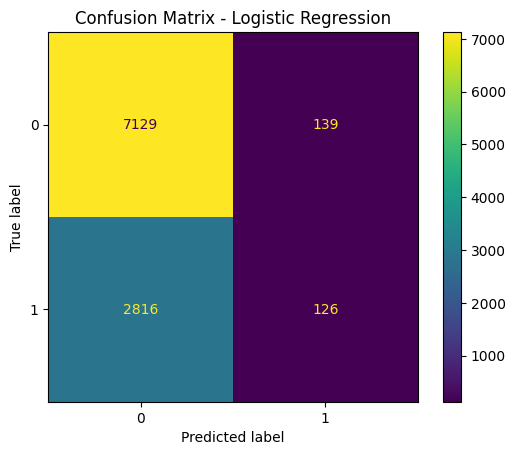


KNN
Best parameters: {'weights': 'uniform', 'p': 1, 'n_neighbors': 7}
CV ROC-AUC: 0.5399434286785092
Test Accuracy: 0.6773751224289912
Balanced Accuracy: 0.5157415499884578
Weighted Precision: 0.6115741435566692
Weighted Recall: 0.6773751224289912
Weighted F1: 0.6240519607344684
Test ROC-AUC: 0.5370481529343495

Confusion Matrix:
[[6521  747]
 [2547  395]]


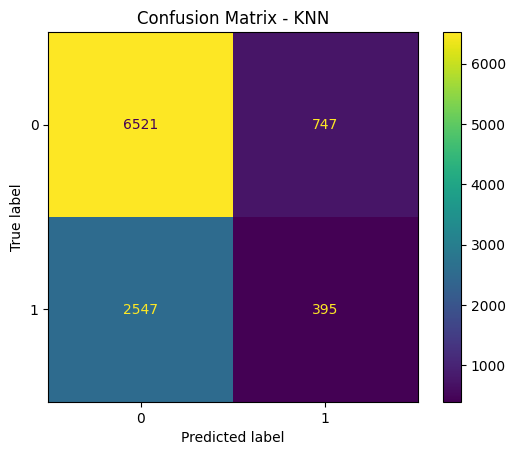


SVM + Kernel SVM
Best parameters: {'C': 1}
CV ROC-AUC: 0.6266105413984004
Test Accuracy: 0.7106758080313418
Balanced Accuracy: 0.508278656109476
Weighted Precision: 0.6442657489291068
Weighted Recall: 0.7106758080313418
Weighted F1: 0.6067527862781195
Test ROC-AUC: 0.6241259189309217

Confusion Matrix:
[[7166  102]
 [2852   90]]


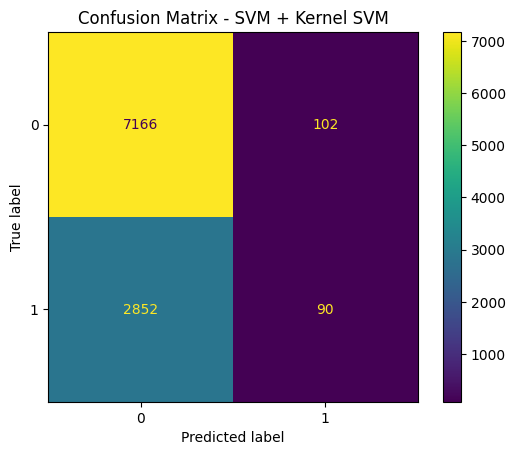


Naive Bayes
Best parameters: {'var_smoothing': 1e-05}
CV ROC-AUC: 0.566905373030353
Test Accuracy: 0.6650342801175319
Balanced Accuracy: 0.5492561752494662
Weighted Precision: 0.6361568955209367
Weighted Recall: 0.6650342801175319
Weighted F1: 0.6462922943543863
Test ROC-AUC: 0.5887520357811096

Confusion Matrix:
[[5978 1290]
 [2130  812]]


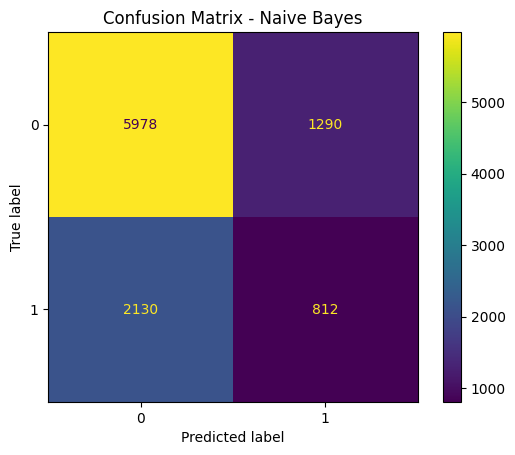


Decision Tree
Best parameters: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5, 'criterion': 'entropy'}
CV ROC-AUC: 0.6286508905314403
Test Accuracy: 0.7129285014691479
Balanced Accuracy: 0.5160315540927571
Weighted Precision: 0.661071595894176
Weighted Recall: 0.7129285014691479
Weighted F1: 0.6173714489238389
Test ROC-AUC: 0.6317515396734594

Confusion Matrix:
[[7128  140]
 [2791  151]]


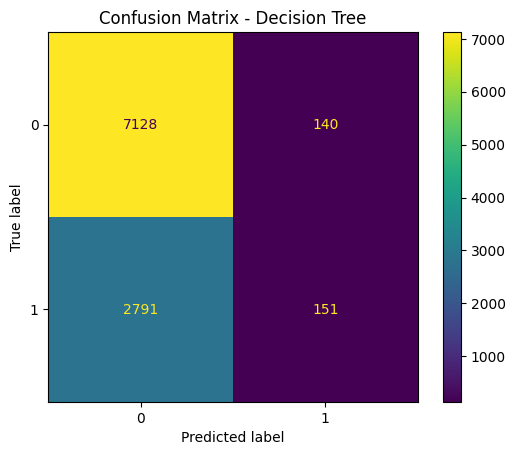


Random Forest
Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 10}
CV ROC-AUC: 0.660856909641538
Test Accuracy: 0.7149853085210578
Balanced Accuracy: 0.5088778389161657
Weighted Precision: 0.6995285086380859
Weighted Recall: 0.7149853085210578
Weighted F1: 0.6051529487671713
Test ROC-AUC: 0.6562656319741755

Confusion Matrix:
[[7234   34]
 [2876   66]]


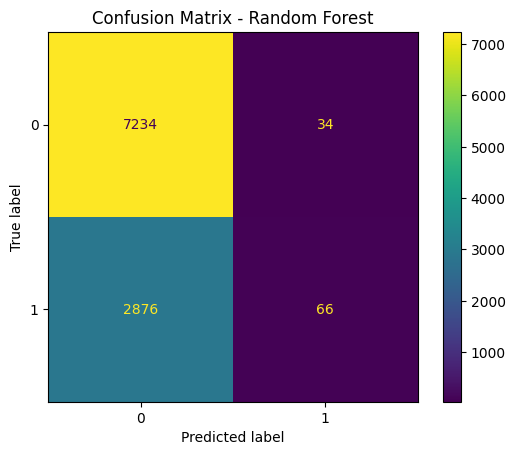


XGBoost Classifier
Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}
CV ROC-AUC: 0.6761113750739538
Test Accuracy: 0.7212536728697355
Balanced Accuracy: 0.5409979096882042
Weighted Precision: 0.6871888545185248
Weighted Recall: 0.7212536728697355
Weighted F1: 0.6475015377158064
Test ROC-AUC: 0.6785400844505421

Confusion Matrix:
[[7024  244]
 [2602  340]]


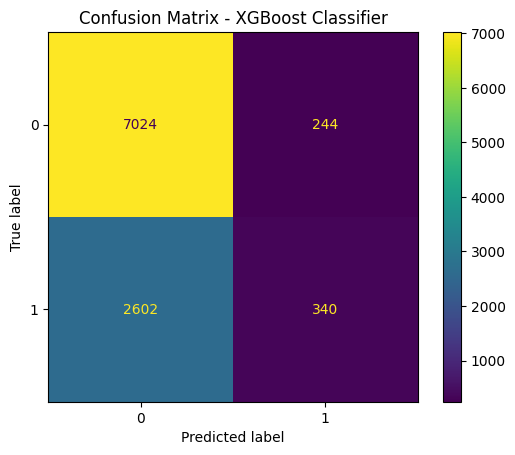


LightGBM Classifier
Best parameters: {'num_leaves': 31, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.05}
CV ROC-AUC: 0.6719822009330909
Test Accuracy: 0.7205680705190989
Balanced Accuracy: 0.5403140312787268
Weighted Precision: 0.6851417854024775
Weighted Recall: 0.7205680705190989
Weighted F1: 0.6468113849380802
Test ROC-AUC: 0.6727382018230272

Confusion Matrix:
[[7019  249]
 [2604  338]]


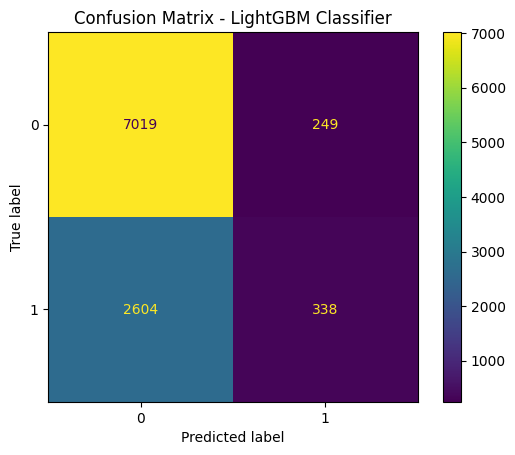


CatBoost Classifier
Best parameters: {'learning_rate': 0.05, 'iterations': 200, 'depth': 6}
CV ROC-AUC: 0.6715026767389208
Test Accuracy: 0.7193927522037218
Balanced Accuracy: 0.5235055785920943
Weighted Precision: 0.6970669156979206
Weighted Recall: 0.7193927522037218
Weighted F1: 0.6254092265591429
Test ROC-AUC: 0.6692900946458161

Confusion Matrix:
[[7165  103]
 [2762  180]]


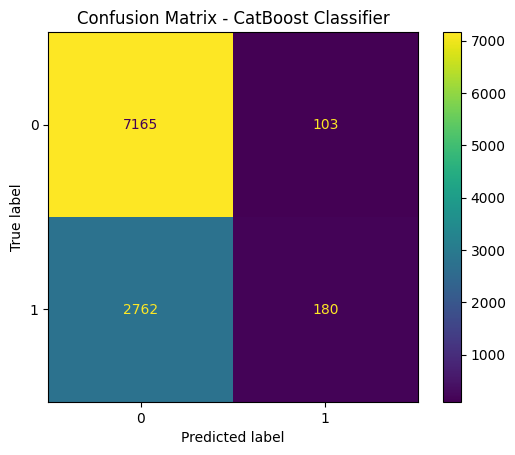

,Model,CV ROC-AUC,Test Accuracy,Balanced Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Test ROC-AUC,Best Hyperparameters
0,XGBoost Classifier,0.676111,0.721254,0.540998,0.687189,0.721254,0.647502,0.678540,"{'subsample': 0.8, 'n_estimators': 200, 'max_d..."
1,LightGBM Classifier,0.671982,0.720568,0.540314,0.685142,0.720568,0.646811,0.672738,"{'num_leaves': 31, 'n_estimators': 200, 'max_d..."
2,CatBoost Classifier,0.671503,0.719393,0.523506,0.697067,0.719393,0.625409,0.669290,"{'learning_rate': 0.05, 'iterations': 200, 'de..."
3,Random Forest,0.660857,0.714985,0.508878,0.699529,0.714985,0.605153,0.656266,"{'n_estimators': 200, 'min_samples_split': 5, ..."
4,Decision Tree,0.628651,0.712929,0.516032,0.661072,0.712929,0.617371,0.631752,"{'min_samples_split': 2, 'min_samples_leaf': 2..."
5,SVM + Kernel SVM,0.626611,0.710676,0.508279,0.644266,0.710676,0.606753,0.624126,{'C': 1}
6,Logistic Regression,0.626558,0.710578,0.511852,0.647292,0.710578,0.612288,0.623973,"{'solver': 'lbfgs', 'penalty': 'l2', 'C': 1}"
7,Naive Bayes,0.566905,0.665034,0.549256,0.636157,0.665034,0.646292,0.588752,{'var_smoothing': 1e-05}
8,KNN,0.539943,0.677375,0.515742,0.611574,0.677375,0.624052,0.537048,"{'weights': 'uniform', 'p': 1, 'n_neighbors': 7}"


Selected model by CV ROC-AUC: XGBoost Classifier
Best CV ROC-AUC: 0.6761113750739538
Final Test ROC-AUC: 0.6785400844505421
Final Test Accuracy: 0.7212536728697355
Selected Hyperparameters:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}


In [11]:
# IMPORTANT:
# Every model is tuned using train.csv only.
# The best configuration is then refit on all of train.csv.
# test.csv remains completely untouched until final evaluation.

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV


# ============================================================
# SVM CONFIGURATION
# ============================================================
# Nonlinear SVMs are used only for smaller datasets.
# For 10,000+ rows, LinearSVC is used because RBF/poly kernels
# become computationally expensive.

N_SAMPLES = X.shape[0]

if N_SAMPLES < 10000:

    svm_model = SVC(
        probability=True,
        random_state=0
    )

    svm_params = [
        {
            "kernel": ["rbf"],
            "C": [0.1, 1, 10, 100],
            "gamma": ["scale", "auto"]
        },
        {
            "kernel": ["poly"],
            "C": [0.1, 1, 10],
            "gamma": ["scale", "auto"],
            "degree": [2, 3]
        }
    ]

else:

    svm_model = LinearSVC(
        random_state=0,
        max_iter=5000
    )

    svm_params = {
        "C": [0.1, 1, 10, 100]
    }


# ============================================================
# MODEL DEFINITIONS
# ============================================================

models = {

    "Logistic Regression": RandomizedSearchCV(
        LogisticRegression(
            max_iter=1000,
            random_state=0
        ),
        {
            "C": [0.01, 0.1, 1, 10, 100],
            "penalty": ["l2"],
            "solver": ["lbfgs"]
        },
        cv=CV,
        scoring="roc_auc",
        n_iter=3,
        n_jobs=1,
        random_state=0
    ),


    "KNN": RandomizedSearchCV(
        KNeighborsClassifier(),
        {
            "n_neighbors": [3, 5, 7, 11],
            "weights": ["uniform", "distance"],
            "p": [1, 2]
        },
        cv=CV,
        scoring="roc_auc",
        n_iter=3,
        n_jobs=1,
        random_state=0
    ),


    "SVM + Kernel SVM": RandomizedSearchCV(
        svm_model,
        svm_params,
        cv=CV,
        scoring="roc_auc",
        n_iter=3,
        n_jobs=-1,
        random_state=0
    ),


    "Naive Bayes": RandomizedSearchCV(
        GaussianNB(),
        {
            "var_smoothing": [
                1e-11,
                1e-9,
                1e-7,
                1e-5
            ]
        },
        cv=CV,
        scoring="roc_auc",
        n_iter=3,
        n_jobs=1,
        random_state=0
    ),


    "Decision Tree": RandomizedSearchCV(
        DecisionTreeClassifier(
            random_state=0
        ),
        {
            "max_depth": [
                None,
                5,
                10,
                20
            ],
            "min_samples_split": [
                2,
                5,
                10
            ],
            "min_samples_leaf": [
                1,
                2,
                4
            ],
            "criterion": [
                "gini",
                "entropy"
            ]
        },
        cv=CV,
        scoring="roc_auc",
        n_iter=3,
        n_jobs=1,
        random_state=0
    ),


    "Random Forest": RandomizedSearchCV(
        RandomForestClassifier(
            random_state=0,
            n_jobs=1
        ),
        {
            "n_estimators": [
                100,
                200
            ],
            "max_depth": [
                None,
                10,
                20
            ],
            "min_samples_split": [
                2,
                5
            ],
            "max_features": [
                "sqrt",
                "log2"
            ]
        },
        cv=CV,
        scoring="roc_auc",
        n_iter=3,
        n_jobs=1,
        random_state=0
    ),


    "XGBoost Classifier": RandomizedSearchCV(
        XGBClassifier(
            random_state=0,
            eval_metric="logloss",
            n_jobs=1
        ),
        {
            "n_estimators": [
                100,
                200
            ],
            "learning_rate": [
                0.05,
                0.1
            ],
            "max_depth": [
                3,
                5
            ],
            "subsample": [
                0.8,
                1.0
            ]
        },
        cv=CV,
        scoring="roc_auc",
        n_iter=3,
        n_jobs=1,
        random_state=0
    ),


    "LightGBM Classifier": RandomizedSearchCV(
        LGBMClassifier(
            random_state=0,
            verbosity=-1,
            n_jobs=1
        ),
        {
            "n_estimators": [
                100,
                200
            ],
            "learning_rate": [
                0.05,
                0.1
            ],
            "num_leaves": [
                15,
                31,
                63
            ],
            "max_depth": [
                -1,
                10
            ]
        },
        cv=CV,
        scoring="roc_auc",
        n_iter=3,
        n_jobs=1,
        random_state=0
    ),


    "CatBoost Classifier": RandomizedSearchCV(
        CatBoostClassifier(
            verbose=False,
            random_seed=0,
            thread_count=-1
        ),
        {
            "iterations": [
                100,
                200
            ],
            "learning_rate": [
                0.05,
                0.1
            ],
            "depth": [
                4,
                6,
                8
            ]
        },
        cv=CV,
        scoring="roc_auc",
        n_iter=3,
        n_jobs=1,
        random_state=0
    )
}


# ============================================================
# ROC-AUC FUNCTION
# ============================================================

def get_roc_auc(model, X_eval, y_eval):
    """Return ROC-AUC when the fitted model exposes usable scores."""

    try:

        if hasattr(model, "predict_proba"):

            scores = model.predict_proba(X_eval)

            if scores.shape[1] == 2:
                return roc_auc_score(
                    y_eval,
                    scores[:, 1]
                )

            return roc_auc_score(
                y_eval,
                scores,
                multi_class="ovr",
                average="weighted"
            )


        if hasattr(model, "decision_function"):

            scores = model.decision_function(X_eval)

            if np.ndim(scores) == 1:
                return roc_auc_score(
                    y_eval,
                    scores
                )

            return roc_auc_score(
                y_eval,
                scores,
                multi_class="ovr",
                average="weighted"
            )

    except Exception:
        return np.nan

    return np.nan


# ============================================================
# TRAIN + FINAL TEST EVALUATION
# ============================================================

results = []


for name, model in models.items():

    print("\n" + "=" * 70)
    print(name)

    # --------------------------------------------------------
    # Hyperparameter tuning happens ONLY on X and y.
    # RandomizedSearchCV also refits the best configuration
    # on the complete training dataset by default.
    # --------------------------------------------------------

    model.fit(X, y)

    best_model = model.best_estimator_

    # --------------------------------------------------------
    # Test set is used ONLY for final evaluation.
    # It does NOT influence hyperparameter selection.
    # --------------------------------------------------------

    predictions = best_model.predict(X_test)


    # ========================================================
    # TEST METRICS
    # ========================================================

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    roc_auc = get_roc_auc(
        best_model,
        X_test,
        y_test
    )

    cm = confusion_matrix(
        y_test,
        predictions
    )


    # ========================================================
    # OUTPUT
    # ========================================================

    print("Best parameters:", model.best_params_)
    print("CV ROC-AUC:", model.best_score_)
    print("Test Accuracy:", accuracy)
    print("Balanced Accuracy:", balanced_accuracy)
    print("Weighted Precision:", precision)
    print("Weighted Recall:", recall)
    print("Weighted F1:", f1)
    print("Test ROC-AUC:", roc_auc)

    print("\nConfusion Matrix:")
    print(cm)


    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=np.unique(y_test)
    ).plot()

    plt.title(
        f"Confusion Matrix - {name}"
    )

    plt.show()


    # ========================================================
    # STORE RESULTS
    # ========================================================

    results.append([
        name,
        model.best_score_,
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        model.best_params_
    ])


# ============================================================
# RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "CV ROC-AUC",
        "Test Accuracy",
        "Balanced Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Test ROC-AUC",
        "Best Hyperparameters"
    ]
)


# ============================================================
# SELECT BEST MODEL USING CV ONLY
# ============================================================
# IMPORTANT:
# Do NOT select the winner using test performance.
# The test set is only for final unbiased evaluation.

results_df = results_df.sort_values(
    "CV ROC-AUC",
    ascending=False
).reset_index(drop=True)


display(results_df)


# ============================================================
# BEST MODEL
# ============================================================

best_row = results_df.iloc[0]

print(
    "Selected model by CV ROC-AUC:",
    best_row["Model"]
)

print(
    "Best CV ROC-AUC:",
    best_row["CV ROC-AUC"]
)

print(
    "Final Test ROC-AUC:",
    best_row["Test ROC-AUC"]
)

print(
    "Final Test Accuracy:",
    best_row["Test Accuracy"]
)

print("Selected Hyperparameters:")
print(
    best_row["Best Hyperparameters"]
)

## Save Best Classification Model

The best classification model is selected using **CV ROC-AUC** and saved as a `.pkl` file.
The saved object contains the fitted model, feature columns, target column, and task metadata.


In [ ]:
# ============================================================
# SAVE BEST CLASSIFICATION MODEL
# ============================================================
# The winner is selected using CV ROC-AUC, not test-set performance.
# The fitted best_estimator_ has already been refit on all training data.

import joblib
from IPython.display import display, FileLink

best_model_name = best_row["Model"]
best_model = models[best_model_name].best_estimator_

classification_model_package = {
    "model": best_model,
    "feature_columns": list(X.columns),
    "target_column": TARGET_COLUMN,
    "task": "classification",
    "selection_metric": "CV ROC-AUC",
    "best_cv_score": float(best_row["CV ROC-AUC"])
}

classification_pkl_path = "best_classification_model.pkl"

joblib.dump(
    classification_model_package,
    classification_pkl_path
)

print("=" * 70)
print("Best classification model saved successfully.")
print("Model:", best_model_name)
print("File:", classification_pkl_path)
print("=" * 70)

display(FileLink(classification_pkl_path, result_html_prefix="⬇️ Download Best Classification Model: "))
